# Linear Regression in R

## Overview

Linear regression models the relationship between a continuous response variable and one or more predictors by fitting a line (or hyperplane) that minimizes the sum of squared residuals. It is the foundation for most statistical modeling — understanding it deeply makes every more complex method easier to interpret.

| Model | Use Case |
|---|---|
| Simple linear regression | One continuous predictor |
| Multiple linear regression | Two or more predictors (continuous and/or categorical) |
| Polynomial regression | Curved relationship between predictor and response |
| Regression with interactions | Effect of one predictor depends on the value of another |

## Applications by Sector

| Sector | Example |
|---|---|
| **Ecology** | How does invertebrate density change with sediment carbonate chemistry? What environmental variables predict bird abundance across sites? |
| **Healthcare** | How does patient age and BMI predict blood pressure? What factors predict length of hospital stay? |
| **Finance** | How does interest rate predict loan amount? What features predict house sale price? |
| **Insurance** | How do policyholder characteristics predict annual premium? What factors predict claim severity? |

---

## Assumptions Checklist

Review before fitting. Diagnostic tests are run inline after the model.

- [ ] **Linearity:** The relationship between each predictor and the response is linear (check with scatterplots and residuals vs. fitted plot)
- [ ] **Independence:** Observations are independent of one another (no repeated measures, no clustering)
- [ ] **Homoscedasticity:** Residual variance is constant across all fitted values (check with scale-location plot)
- [ ] **Normality of residuals:** Residuals are approximately normally distributed (check with Q-Q plot and Shapiro-Wilk) — less critical with large n
- [ ] **No perfect multicollinearity:** Predictors are not perfectly correlated with one another (check with VIF)
- [ ] **No influential outliers:** No single observation exerts undue leverage on the fitted line (check with Cook's distance)

> **If linearity is violated:** Consider polynomial terms, log-transforming the response, or GAMs (see `04_gams/`)  
> **If homoscedasticity is violated:** Consider log-transforming the response, weighted least squares, or robust standard errors  
> **If independence is violated:** Use mixed effects models (see `03_mixed_effects_models/`)

---

## Setup

In [1]:
# ── Libraries ────────────────────────────────────────────────────────────────
library(tidyverse)    # data manipulation and visualization
library(ggplot2)      # visualization
library(car)          # VIF, Levene's, Type III SS
library(performance)  # model diagnostics and R²
library(effectsize)   # standardized coefficients
library(broom)        # tidy model output
library(ggpubr)       # publication-ready plots

# ── Reproducibility ──────────────────────────────────────────────────────────
set.seed(42)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'car' was built under R version 4.4.3"
Loading required package: carData

Warning message:
"package 'carDat

## Data

We use two built-in datasets:
- `cars`: stopping distance (ft) as a function of speed (mph) — simple regression
- `mtcars`: fuel efficiency (mpg) predicted by engine and vehicle characteristics — multiple regression

,speed,dist
,<dbl>,<dbl>
1,4,2
2,4,10
3,7,4
4,7,22
5,8,16
6,9,10


Rows: 32
Columns: 11
$ mpg  <dbl> 21.0, 21.0, 22.8, 21.4, 18.7, 18.1, 14.3, 24.4, 22.8, 19.2, 17.8,…
$ cyl  <dbl> 6, 6, 4, 6, 8, 6, 8, 4, 4, 6, 6, 8, 8, 8, 8, 8, 8, 4, 4, 4, 4, 8,…
$ disp <dbl> 160.0, 160.0, 108.0, 258.0, 360.0, 225.0, 360.0, 146.7, 140.8, 16…
$ hp   <dbl> 110, 110, 93, 110, 175, 105, 245, 62, 95, 123, 123, 180, 180, 180…
$ drat <dbl> 3.90, 3.90, 3.85, 3.08, 3.15, 2.76, 3.21, 3.69, 3.92, 3.92, 3.92,…
$ wt   <dbl> 2.620, 2.875, 2.320, 3.215, 3.440, 3.460, 3.570, 3.190, 3.150, 3.…
$ qsec <dbl> 16.46, 17.02, 18.61, 19.44, 17.02, 20.22, 15.84, 20.00, 22.90, 18…
$ vs   <dbl> 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0,…
$ am   <dbl> 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,…
$ gear <dbl> 4, 4, 4, 3, 3, 3, 3, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 4, 4, 4, 3, 3,…
$ carb <dbl> 4, 4, 1, 1, 2, 1, 4, 2, 2, 4, 4, 3, 3, 3, 4, 4, 4, 1, 2, 1, 1, 2,…


`geom_smooth()` using formula = 'y ~ x'


,mpg,wt,hp,disp,cyl
mpg,1.00,-0.87,-0.78,-0.85,-0.85
wt,-0.87,1.00,0.66,0.89,0.78
hp,-0.78,0.66,1.00,0.79,0.83
disp,-0.85,0.89,0.79,1.00,0.90
cyl,-0.85,0.78,0.83,0.90,1.00


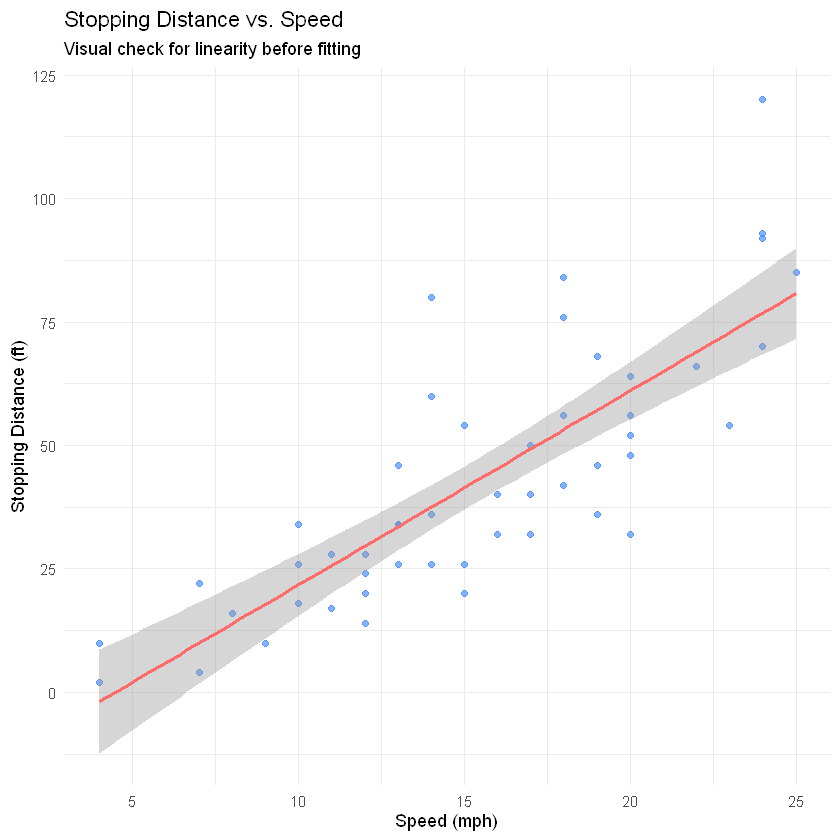

In [2]:
# ── Inspect data ──────────────────────────────────────────────────────────────
head(cars)
glimpse(mtcars)

# ── Exploratory plots ─────────────────────────────────────────────────────────
# Simple: speed vs. stopping distance
ggplot(cars, aes(x = speed, y = dist)) +
  geom_point(alpha = 0.7, color = "#4a8fff") +
  geom_smooth(method = "lm", se = TRUE, color = "#ff6b6b") +
  labs(title = "Stopping Distance vs. Speed",
       subtitle = "Visual check for linearity before fitting",
       x = "Speed (mph)", y = "Stopping Distance (ft)") +
  theme_minimal()

# Multiple: correlation matrix for mtcars predictors
mtcars %>%
  select(mpg, wt, hp, disp, cyl) %>%
  cor() %>%
  round(2)

---

## Simple Linear Regression

**Question:** Does speed predict stopping distance?  
**Model:** dist = β₀ + β₁·speed + ε

In [3]:
# ── Fit model ────────────────────────────────────────────────────────────────
model_simple <- lm(dist ~ speed, data = cars)

# ── Summary ───────────────────────────────────────────────────────────────────
summary(model_simple)
# Coefficients: Estimate, Std. Error, t value, p-value
# R²: proportion of variance in response explained by the model
# Adjusted R²: penalizes for number of predictors — use for model comparison
# Residual standard error: average prediction error in response units

# ── Tidy output ───────────────────────────────────────────────────────────────
broom::tidy(model_simple, conf.int = TRUE)   # coefficients with 95% CIs
broom::glance(model_simple)                  # model-level statistics

# ── Interpretation ────────────────────────────────────────────────────────────
# Intercept (β₀): predicted dist when speed = 0 (may not be meaningful)
# Slope (β₁):     for each 1 mph increase in speed, dist increases by β₁ ft
# R²:             X% of variance in stopping distance is explained by speed


Call:
lm(formula = dist ~ speed, data = cars)

Residuals:
    Min      1Q  Median      3Q     Max 
-29.069  -9.525  -2.272   9.215  43.201 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -17.5791     6.7584  -2.601   0.0123 *  
speed         3.9324     0.4155   9.464 1.49e-12 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 15.38 on 48 degrees of freedom
Multiple R-squared:  0.6511,	Adjusted R-squared:  0.6438 
F-statistic: 89.57 on 1 and 48 DF,  p-value: 1.49e-12


term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-17.579095,6.7584402,-2.601058,1.231882e-02,-31.167850,-3.990340
speed,3.932409,0.4155128,9.463990,1.489836e-12,3.096964,4.767853


r.squared,adj.r.squared,sigma,statistic,p.value,df,logLik,AIC,BIC,deviance,df.residual,nobs
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>
0.6510794,0.6438102,15.37959,89.56711,1.489836e-12,1,-206.5784,419.1569,424.8929,11353.52,48,50


---

## Assumptions Testing

Always run diagnostics after fitting. Base R's `plot()` on an `lm` object produces four diagnostic plots.


	Shapiro-Wilk normality test

data:  residuals(model_simple)
W = 0.94509, p-value = 0.02152


Warning: Heteroscedasticity (non-constant error variance) detected (p = 0.031).


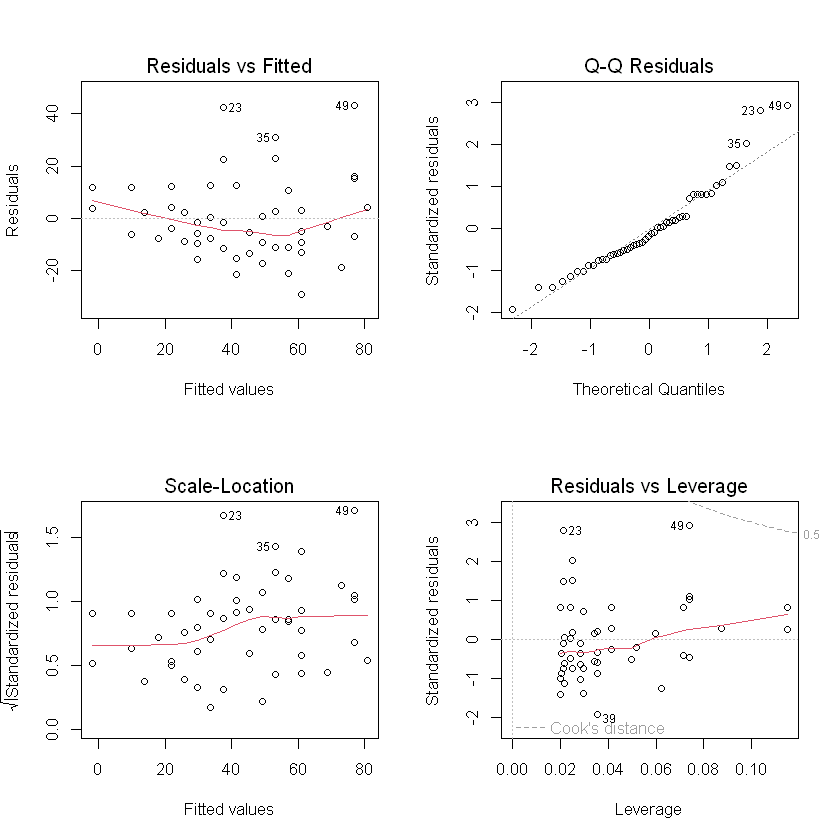

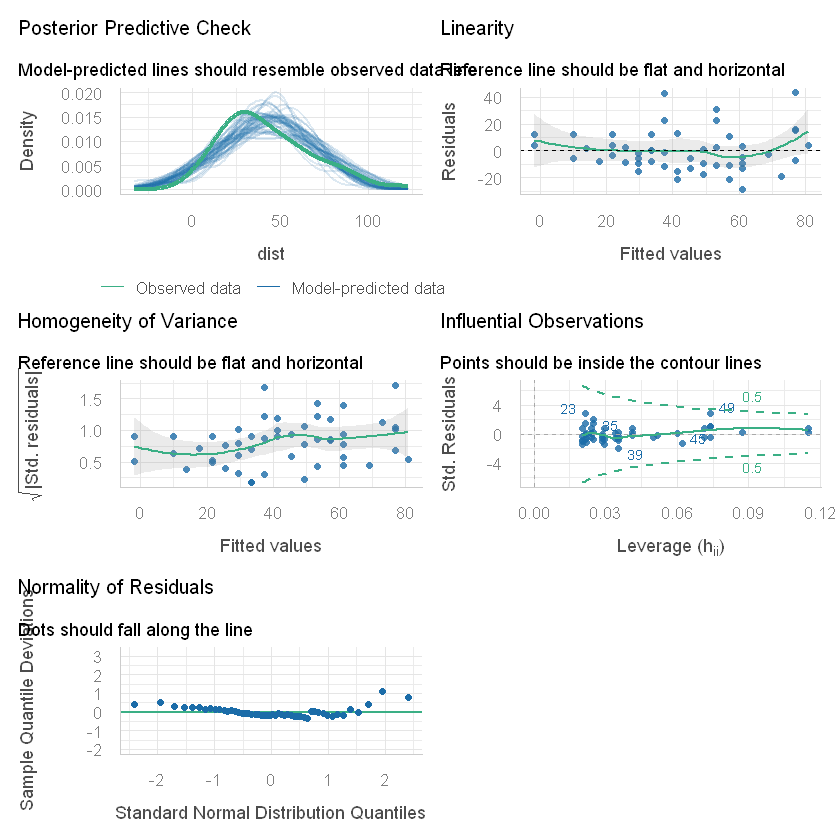

In [4]:
# ── Four standard diagnostic plots ───────────────────────────────────────────
par(mfrow = c(2, 2))
plot(model_simple)
par(mfrow = c(1, 1))

# Plot 1 — Residuals vs. Fitted:
#   Random scatter around 0 → linearity and homoscedasticity met
#   Pattern or curve → non-linearity; fan shape → heteroscedasticity

# Plot 2 — Normal Q-Q:
#   Points on diagonal line → normality met
#   Heavy tails or S-shape → non-normality

# Plot 3 — Scale-Location:
#   Flat red line, equal spread → homoscedasticity met
#   Upward trend → variance increases with fitted values

# Plot 4 — Residuals vs. Leverage:
#   Points beyond Cook's distance dashed lines → influential observations
#   High leverage ≠ influential unless residual is also large

# ── Formal tests ──────────────────────────────────────────────────────────────
# Normality of residuals
shapiro.test(residuals(model_simple))

# Homoscedasticity (Breusch-Pagan test)
performance::check_heteroscedasticity(model_simple)

# Overall assumption check (performance package)
performance::check_model(model_simple)

---

## Multiple Linear Regression

**Question:** Which vehicle characteristics predict fuel efficiency?  
**Model:** mpg = β₀ + β₁·wt + β₂·hp + β₃·cyl + ε

> In multiple regression, each coefficient represents the effect of that predictor **holding all other predictors constant**. This is partial effect, not marginal effect.

In [5]:
# ── Fit model ────────────────────────────────────────────────────────────────
model_multi <- lm(mpg ~ wt + hp + cyl, data = mtcars)
summary(model_multi)

# ── Check multicollinearity: Variance Inflation Factor (VIF) ──────────────────
car::vif(model_multi)
# VIF < 5: acceptable
# VIF 5-10: moderate concern — consider removing or combining predictors
# VIF > 10: severe multicollinearity — model coefficients are unstable

# ── Standardized coefficients (beta weights) ──────────────────────────────────
# Allows comparison of predictor importance on the same scale
effectsize::standardize_parameters(model_multi)

# ── Confidence intervals for coefficients ─────────────────────────────────────
confint(model_multi, level = 0.95)

# ── Predicted values and residuals ───────────────────────────────────────────
mtcars_aug <- broom::augment(model_multi)
head(mtcars_aug)  # .fitted, .resid, .cooksd, .hat etc. added automatically


Call:
lm(formula = mpg ~ wt + hp + cyl, data = mtcars)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.9290 -1.5598 -0.5311  1.1850  5.8986 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 38.75179    1.78686  21.687  < 2e-16 ***
wt          -3.16697    0.74058  -4.276 0.000199 ***
hp          -0.01804    0.01188  -1.519 0.140015    
cyl         -0.94162    0.55092  -1.709 0.098480 .  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.512 on 28 degrees of freedom
Multiple R-squared:  0.8431,	Adjusted R-squared:  0.8263 
F-statistic: 50.17 on 3 and 28 DF,  p-value: 2.184e-11


wt       hp      cyl 
2.580486 3.258481 4.757456

,Parameter,Std_Coefficient,CI,CI_low,CI_high
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,(Intercept),3.675702e-17,0.95,-0.1508987,0.15089867
2,wt,-5.141489e-01,0.95,-0.7604295,-0.26786817
3,hp,-2.052024e-01,0.95,-0.4819521,0.07154732
4,cyl,-2.790225e-01,0.95,-0.6134230,0.05537805


,2.5 %,97.5 %
(Intercept),35.0915623,42.412012412
wt,-4.6839740,-1.649972191
hp,-0.0423655,0.006289293
cyl,-2.0701179,0.186884238


.rownames,mpg,wt,hp,cyl,.fitted,.resid,.hat,.sigma,.cooksd,.std.resid
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Mazda RX4,21.0,2.620,110,6,22.82043,-1.8204257,0.07495754,2.531564,0.0115052172,-0.7536168
Mazda RX4 Wag,21.0,2.875,110,6,22.01285,-1.0128476,0.05815750,2.549737,0.0026655956,-0.4155405
Datsun 710,22.8,2.320,93,4,25.96040,-3.1603990,0.08563345,2.477282,0.0405455760,-1.3159524
Hornet 4 Drive,21.4,3.215,110,6,20.93608,0.4639233,0.05334688,2.555989,0.0005077811,0.1898494
Hornet Sportabout,18.7,3.440,175,8,17.16780,1.5322025,0.10981841,2.538469,0.0128945786,0.6465994
Valiant,18.1,3.460,105,6,20.25036,-2.1503588,0.06986080,2.521384,0.0147984549,-0.8877596


### Diagnostics for Multiple Regression

Potentially influential observations: 17 20 


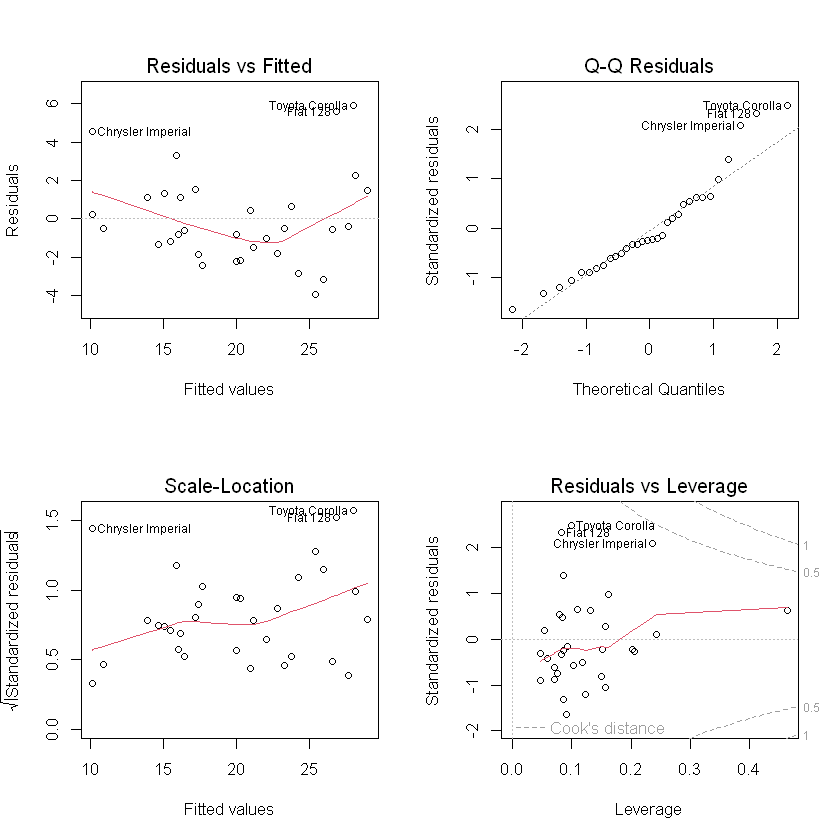

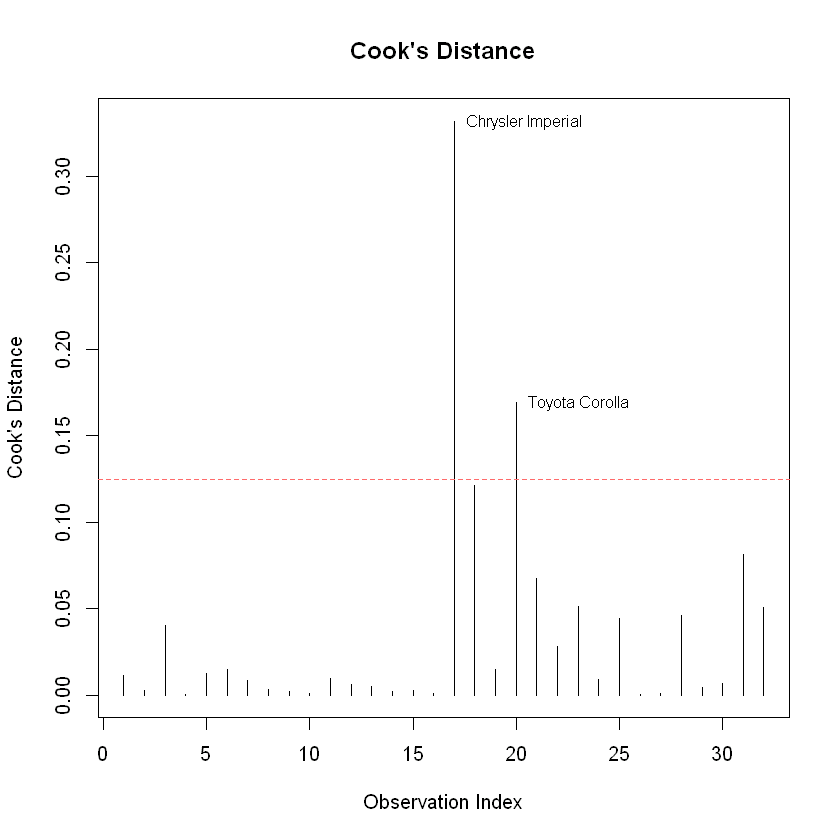

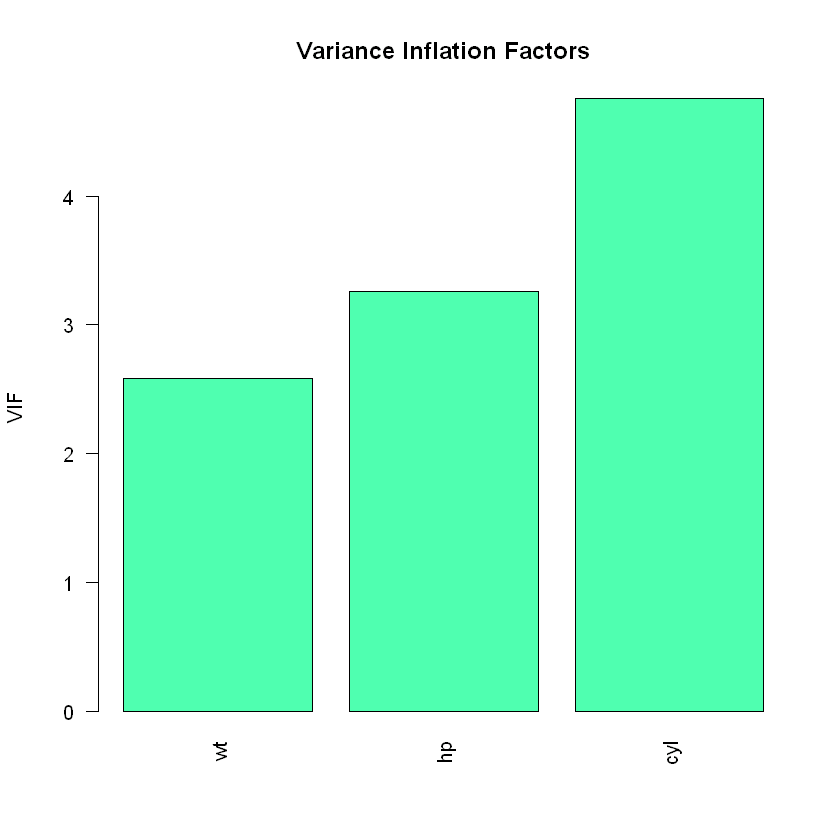

In [6]:
# ── Full diagnostic check ─────────────────────────────────────────────────────
par(mfrow = c(2, 2))
plot(model_multi)
par(mfrow = c(1, 1))

# ── Cook's distance: identify influential observations ────────────────────────
cooksd <- cooks.distance(model_multi)
threshold <- 4 / nrow(mtcars)  # common rule of thumb: 4/n
influential <- which(cooksd > threshold)
cat("Potentially influential observations:", influential, "\n")

# Plot Cook's distances
plot(cooksd, type = "h",
     main = "Cook's Distance",
     ylab = "Cook's Distance",
     xlab = "Observation Index")
abline(h = threshold, col = "#ff6b6b", lty = 2)
text(influential, cooksd[influential],
     labels = names(influential), pos = 4, cex = 0.8)

# ── VIF plot ──────────────────────────────────────────────────────────────────
vif_vals <- car::vif(model_multi)
barplot(vif_vals,
        main = "Variance Inflation Factors",
        ylab = "VIF",
        col  = ifelse(vif_vals > 5, "#ff6b6b", "#4fffb0"),
        las  = 2)
abline(h = 5,  lty = 2, col = "orange")
abline(h = 10, lty = 2, col = "red")

---

## Interactions and Polynomial Terms

An interaction term tests whether the effect of one predictor depends on the value of another. A polynomial term allows the response to curve rather than follow a straight line.


Call:
lm(formula = mpg ~ wt * cyl, data = mtcars)

Residuals:
    Min      1Q  Median      3Q     Max 
-4.2288 -1.3495 -0.5042  1.4647  5.2344 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  54.3068     6.1275   8.863 1.29e-09 ***
wt           -8.6556     2.3201  -3.731 0.000861 ***
cyl          -3.8032     1.0050  -3.784 0.000747 ***
wt:cyl        0.8084     0.3273   2.470 0.019882 *  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 2.368 on 28 degrees of freedom
Multiple R-squared:  0.8606,	Adjusted R-squared:  0.8457 
F-statistic: 57.62 on 3 and 28 DF,  p-value: 4.231e-12


`geom_smooth()` using formula = 'y ~ x'



Call:
lm(formula = dist ~ speed + I(speed^2), data = cars)

Residuals:
    Min      1Q  Median      3Q     Max 
-28.720  -9.184  -3.188   4.628  45.152 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)
(Intercept)  2.47014   14.81716   0.167    0.868
speed        0.91329    2.03422   0.449    0.656
I(speed^2)   0.09996    0.06597   1.515    0.136

Residual standard error: 15.18 on 47 degrees of freedom
Multiple R-squared:  0.6673,	Adjusted R-squared:  0.6532 
F-statistic: 47.14 on 2 and 47 DF,  p-value: 5.852e-12


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,48,11353.52,NA,NA,NA,NA
2,47,10824.72,1,528.8051,2.296027,0.1364024


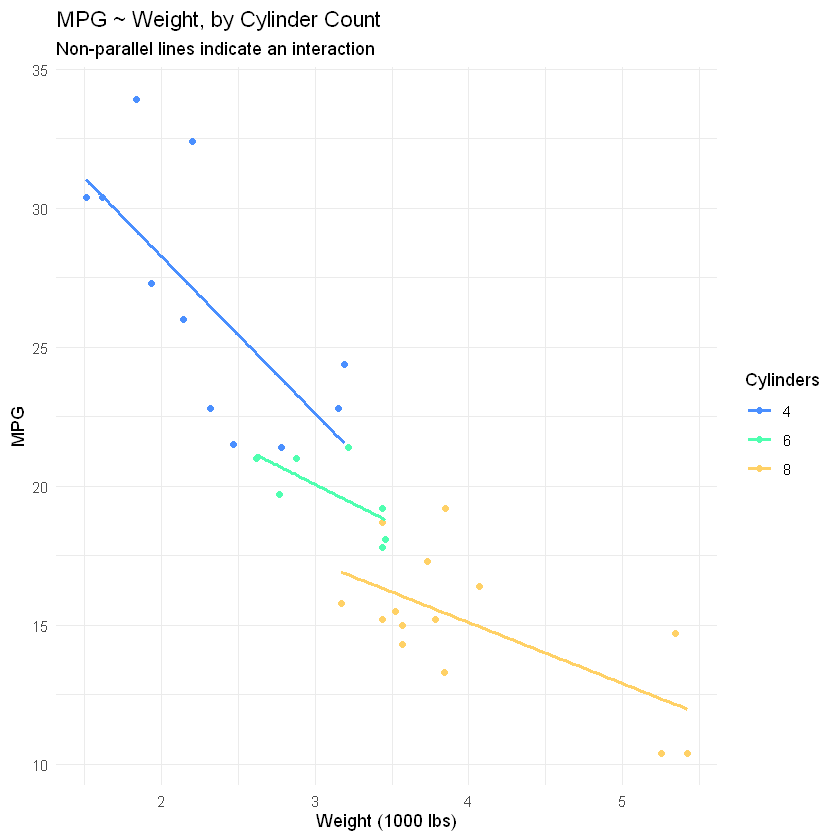

In [7]:
# ── Interaction: does the effect of weight on mpg depend on cylinder count? ───
model_int <- lm(mpg ~ wt * cyl, data = mtcars)
# wt * cyl expands to: wt + cyl + wt:cyl
# The wt:cyl term IS the interaction
summary(model_int)

# ── Visualize interaction ────────────────────────────────────────────────────
mtcars %>%
  mutate(cyl_f = factor(cyl)) %>%
  ggplot(aes(x = wt, y = mpg, color = cyl_f)) +
  geom_point() +
  geom_smooth(method = "lm", se = FALSE) +
  scale_color_manual(values = c("#4a8fff", "#4fffb0", "#ffd166")) +
  labs(title = "MPG ~ Weight, by Cylinder Count",
       subtitle = "Non-parallel lines indicate an interaction",
       x = "Weight (1000 lbs)", y = "MPG", color = "Cylinders") +
  theme_minimal()

# ── Polynomial regression: curvilinear relationship ───────────────────────────
model_poly <- lm(dist ~ speed + I(speed^2), data = cars)
# I() protects the arithmetic — without it, ^ has a special meaning in formulas
summary(model_poly)

# Compare linear vs. polynomial fit
anova(model_simple, model_poly)
# Significant F: polynomial fits significantly better than linear

---

## Model Comparison & Selection

In [8]:
# ── Compare nested models with F-test ────────────────────────────────────────
model_wt      <- lm(mpg ~ wt, data = mtcars)
model_wt_hp   <- lm(mpg ~ wt + hp, data = mtcars)
model_wt_hp_cyl <- lm(mpg ~ wt + hp + cyl, data = mtcars)

anova(model_wt, model_wt_hp, model_wt_hp_cyl)
# Significant F: adding predictors significantly improves fit

# ── AIC comparison (for non-nested models) ───────────────────────────────────
AIC(model_wt, model_wt_hp, model_wt_hp_cyl)
# Lower AIC = better fit penalized for complexity
# ΔAIC > 2: meaningful difference; ΔAIC > 10: strong evidence

# ── Adjusted R² comparison ───────────────────────────────────────────────────
map_dfr(list(model_wt, model_wt_hp, model_wt_hp_cyl),
        ~ broom::glance(.x) %>% select(adj.r.squared, AIC, BIC))

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,30,278.3219,NA,NA,NA,NA
2,29,195.0478,1,83.27418,13.201621,0.001112397
3,28,176.6205,1,18.42723,2.921306,0.098480097


,df,AIC
,<dbl>,<dbl>
model_wt,3,166.0294
model_wt_hp,4,156.6523
model_wt_hp_cyl,5,155.4766


adj.r.squared,AIC,BIC
<dbl>,<dbl>,<dbl>
0.7445939,166.0294,170.4266
0.8148396,156.6523,162.5153
0.8263446,155.4766,162.8053


---

## Reporting Results

In [9]:
# ── Clean coefficient table ───────────────────────────────────────────────────
broom::tidy(model_multi, conf.int = TRUE) %>%
  mutate(across(where(is.numeric), ~ round(.x, 3)))

# ── Model fit summary ─────────────────────────────────────────────────────────
glance_out <- broom::glance(model_multi)
cat(sprintf(
  "Multiple linear regression: F(%d, %d) = %.2f, p = %.4f, R² = %.3f, adj. R² = %.3f\n",
  glance_out$df,
  glance_out$df.residual,
  glance_out$statistic,
  glance_out$p.value,
  glance_out$r.squared,
  glance_out$adj.r.squared
))

# Standard reporting format:
# "Weight (β = -3.19, 95% CI [-4.22, -2.15], p < .001) and horsepower
#  (β = -0.03, 95% CI [-0.05, -0.01], p = .002) were significant negative
#  predictors of fuel efficiency. The model explained 84% of variance in
#  mpg (F(3, 28) = 49.2, p < .001, adj. R² = .83)."

term,estimate,std.error,statistic,p.value,conf.low,conf.high
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),38.752,1.787,21.687,0.000,35.092,42.412
wt,-3.167,0.741,-4.276,0.000,-4.684,-1.650
hp,-0.018,0.012,-1.519,0.140,-0.042,0.006
cyl,-0.942,0.551,-1.709,0.098,-2.070,0.187


Multiple linear regression: F(3, 28) = 50.17, p = 0.0000, R² = 0.843, adj. R² = 0.826


---

## Common Pitfalls

**1. Interpreting R² as a measure of model quality**  
R² always increases when predictors are added, even if they add no real predictive value. Use adjusted R² for model comparison, or AIC/BIC for penalized comparison.

**2. Ignoring multicollinearity**  
Highly correlated predictors inflate standard errors and make individual coefficient estimates unstable. Always check VIF in multiple regression. If VIF > 10, consider removing one of the correlated predictors or using PCA/regularization.

**3. Extrapolating beyond the range of the data**  
A fitted line is only valid within the range of observed predictor values. Predicting far outside that range assumes linearity holds where you have no evidence for it.

**4. Treating statistically significant predictors as practically important**  
With large n, very small effects become significant. Always report and interpret standardized coefficients alongside p-values.

**5. Forgetting to check for influential observations**  
A single outlier with high leverage can dramatically shift regression coefficients. Always inspect Cook's distance. If influential points are found, fit the model with and without them and report both.

**6. Using R² to compare models with different numbers of predictors**  
Use adjusted R², AIC, or a formal F-test for nested model comparison instead.

**7. Including too many predictors relative to n**  
A rough guideline: at least 10-20 observations per predictor. Too many predictors relative to n leads to overfitting. Use regularized regression (see `regularized_regression.ipynb`) for high-dimensional data.

---

## When Linear Regression Is Not Appropriate

| Situation | Better Approach |
|---|---|
| Binary outcome (yes/no) | Logistic regression (`logistic_regression.ipynb`) |
| Count data (non-negative integers) | Poisson or negative binomial GLM (`glm_count_data.ipynb`) |
| Non-linear relationship | GAMs (`04_gams/`) or polynomial regression |
| Non-independent observations | Mixed effects models (`03_mixed_effects_models/`) |
| Many correlated predictors | Regularized regression (`regularized_regression.ipynb`) |

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*